🔍 Average raw intensity values from testMID (used for normalization):
2aP1_kymo1     54562.347377
2aP1_kymo2     59470.921541
2aP1_kymo3     61125.096377
2aP1_kymo4     58237.314230
2aP1_kymo5     53183.312754
2aP2_kymo1     58191.072984
2aP2_kymo5     48790.758623
2aP2_kymo13    54309.796836
2aP2_kymo18    59525.818574
2aP2_kymo12    58983.771033
2ap3_kymo6     52039.350672
2ap3_kymo11    53639.668656
2ap3_kymo12    50309.586164
dtype: float64
✅ All files saved
2aP1_kymo1     float64
2aP1_kymo2     float64
2aP1_kymo3     float64
2aP1_kymo4     float64
2aP1_kymo5     float64
2aP2_kymo1     float64
2aP2_kymo5     float64
2aP2_kymo13    float64
2aP2_kymo18    float64
2aP2_kymo12    float64
2ap3_kymo6     float64
2ap3_kymo11    float64
2ap3_kymo12    float64
dtype: object
2aP1_kymo1     float64
2aP1_kymo2     float64
2aP1_kymo3     float64
2aP1_kymo4     float64
2aP1_kymo5     float64
2aP2_kymo1     float64
2aP2_kymo5     float64
2aP2_kymo13    float64
2aP2_kymo18    float64
2aP2_kymo12  

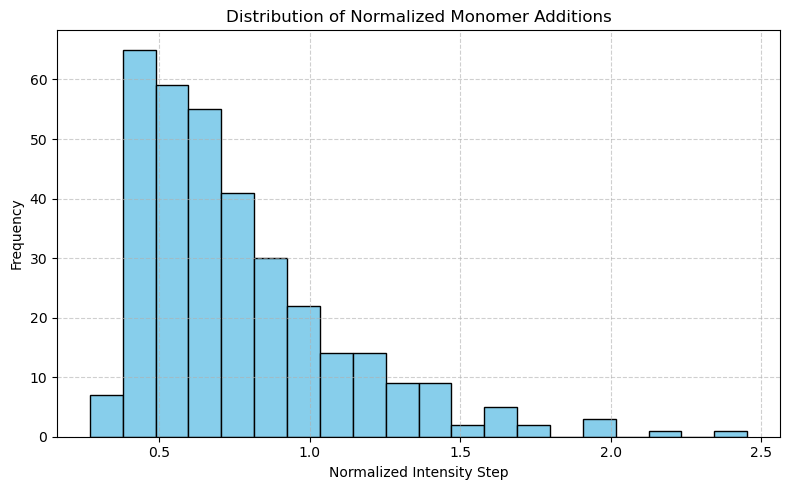

In [2]:
#must edit normalization factor based on labelling ratio of the sample

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

output_dir = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\test'

# --- File paths ---
mid_file = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\test\AMPPNP_IntMID.xlsx'
be_file = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\test\AMPPNP_IntBE.xlsx'
outputMID = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\test\AMPPNPoutputMID.xlsx'
outputBE = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\test\AMPPNPoutputBE.xlsx'
outputNZ = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\test\AMPPNPoutputNZ.xlsx'
outputMON = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\test\AMPPNPoutputMON.xlsx'

# --- Step 1: Read input files ---
mid_df = pd.read_excel(mid_file)
be_df = pd.read_excel(be_file)

# Ensure time column is preserved
time_col = mid_df.iloc[:, 0]
mid_data = mid_df.iloc[:, 1:]
be_data = be_df.iloc[:, 1:]

# Convert to numeric
mid_data = mid_data.apply(pd.to_numeric, errors='coerce')
be_data = be_data.apply(pd.to_numeric, errors='coerce')

# --- Step 2: Compute absolute step differences ---
mid_diff = mid_data.diff().abs().iloc[1:].reset_index(drop=True)
be_diff = be_data.diff().abs().iloc[1:].reset_index(drop=True)
time_diff = time_col.iloc[1:].reset_index(drop=True)


# Re-add time column to outputMID
outputMID_df = pd.concat([time_diff, mid_diff], axis=1)
outputMID_df.to_excel(outputMID, index=False)

# Re-add time column to outputBE
outputBE_df = pd.concat([time_diff, be_diff], axis=1)
outputBE_df.to_excel(outputBE, index=False)

# --- Step 3: Threshold BE steps using MID averages ---
mid_step_means = mid_diff.mean()
thresholded_be = be_diff.copy()

for col in be_diff.columns:
    threshold = mid_step_means[col]
    thresholded_be[col] = be_diff[col].apply(lambda x: x if x > threshold else 0)

# --- Step 4: Filter out zero values column-wise ---
nonzero_filtered = {}
for col in thresholded_be.columns:
    nonzero_filtered[col] = thresholded_be[col][thresholded_be[col] > 0].reset_index(drop=True)

outputNZ_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in nonzero_filtered.items()]))
outputNZ_df.to_excel(outputNZ, index=False)



# --- Step 5: Normalize by average intensity from original MID ---
mid_avg_intensity = mid_data.mean()

print("🔍 Average raw intensity values from testMID (used for normalization):")
print(mid_avg_intensity)
mid_avg_intensity.to_excel('AvgInt_AMPPNP_MID.xlsx', header=['Average Intensity']) 
#export average intensity for columns in testMID to excel


normalized_MON = pd.DataFrame()

for col in outputNZ_df.columns:
    normalization_factor = mid_avg_intensity[col] / 18.29
    if normalization_factor != 0:
        normalized_MON[col] = outputNZ_df[col] / normalization_factor
    else:
        normalized_MON[col] = outputNZ_df[col]  # avoid division by zero


normalized_MON.to_excel(outputMON, index=False)

print("✅ All files saved")
print(mid_data.dtypes)
print(be_data.dtypes)

# --- Load outputMON.xlsx ---
df = pd.read_excel(outputMON)

# --- Flatten all values into a 1D array and drop NaNs ---
all_values = df.values.flatten()
all_values = all_values[~pd.isna(all_values)]

# --- Generate histogram data ---
counts, bin_edges = np.histogram(all_values, bins='auto')

# --- Plot histogram ---
plt.figure(figsize=(8, 5))
plt.hist(all_values, bins=bin_edges, color='skyblue', edgecolor='black')
plt.title('Distribution of Normalized Monomer Additions')
plt.xlabel('Normalized Intensity Step')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


# --- Save histogram plot ---
hist_plot_path = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\test\AMPPNPNormMonomer_Histogram.png'
plt.savefig(hist_plot_path, dpi=300)
plt.show()

# --- Prepare histogram data for export ---
hist_df = pd.DataFrame({
    'Bin_Start': bin_edges[:-1],
    'Bin_End': bin_edges[1:],
    'Frequency': counts
})

# --- Save histogram data to Excel ---
histogram_excel_path = os.path.join(output_dir, 'HistoData_AMPPNPoutputMON.xlsx')
hist_df.to_excel(histogram_excel_path, index=False)

# --- Save mid_avg_intensity (used for normalization) ---
avg_intensity_path = os.path.join(output_dir, 'AvgInt_AMPPNP_MID.xlsx')
mid_avg_intensity_df = pd.DataFrame(mid_avg_intensity).reset_index()
mid_avg_intensity_df.columns = ['Filament', 'Average_Intensity']
mid_avg_intensity_df.to_excel(avg_intensity_path, index=False)

